In [1]:
import torch.nn as nn
import timm
import seaborn as sns
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from pathlib import Path
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Subset
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

import torch
import cv2
import os

DATA_DIR = "/kaggle/input/datasets/raddar/chest-xrays-indiana-university"
OUTPUT_DIR = "/kaggle/working/"

os.makedirs(OUTPUT_DIR, exist_ok=True)

if os.path.exists(DATA_DIR):
    print(f"content:")
    for item in os.listdir(DATA_DIR):
        print(f"  - {item}")
        if os.path.isdir(os.path.join(DATA_DIR, item)):
            subdir = os.path.join(DATA_DIR, item)
            for subitem in os.listdir(subdir)[:3]:
                print(f"      {subitem}")
else:
    print(f"\nWARNING: Dataset path not found: {DATA_DIR}")
    print("Available input directories:")
    !ls -la /kaggle/input/

IMG_SIZE = 300
NUM_EPOCHS = 20
BATCH_SIZE = 32
NUM_WORKERS = 4

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=5, p=0.3),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2()
])

c:\Users\ilisa\Desktop\EfficientNet + YOLO Med Proj\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Available input directories:


'ls' is not recognized as an internal or external command,
operable program or batch file.


In [2]:
class AugmentedDataset:
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform
    
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        actual_idx = self.indices[idx]
        image, label = self.dataset[actual_idx]
        
        if isinstance(image, torch.Tensor):
            image = image.permute(1, 2, 0).numpy()
            image = ((image * 0.5 + 0.5) * 255).astype(np.uint8)
        
        transformed = self.transform(image=image)
        return transformed['image'], label

In [3]:
# Split the images to [0: NORMAL, 1:SICK]
class XRayDataset(Dataset):
    def __init__(self, path, img_size=300, transform=None, augment=False, use_projection='both'):
        self.path = Path(path)
        self.img_size = img_size
        self.transform = transform
        self.augment = augment
        
        self.use_projection = use_projection
        
        print("Loading Indiana Chest X-ray dataset...")
        
        projections = pd.read_csv(self.path / 'indiana_projections.csv')
        reports = pd.read_csv(self.path / 'indiana_reports.csv')
        
        
        reports['label'] = reports['Problems'].apply(
            lambda x: 0 if pd.isna(x) or 'normal' in str(x).lower() else 1
        )
        
        merged = pd.merge(projections, reports[['uid', 'label']], on='uid', how='inner')
        
        if self.use_projection != 'both':
            merged = merged[merged['projection'].str.lower() == self.use_projection]
            print(f"use {self.use_projection} projections")
            
        self.samples = []
        projection_counts = {'frontal': 0, 'lateral': 0}
        
        for _, row in merged.iterrows():
            img_path = self.path / 'images' / 'images_normalized' / row['filename']
            if img_path.exists():
                self.samples.append({
                    'path': str(img_path),
                    'label': row['label'],
                    'projection': row['projection']
                })
                projection_counts[row['projection'].lower()] += 1
        
        print(f"loaded {len(self.samples)} images")
        if len(self.samples) > 0:
            labels = [s['label'] for s in self.samples]
            normal = sum(1 for l in labels if l == 0)
            sick = len(labels) - normal
            print(f"Normal: {normal} ({normal/len(labels)*100:.1f}%)")
            print(f"Sick: {sick} ({sick/len(labels)*100:.1f}%)")
            print(f"Projections: Frontal={projection_counts['frontal']}, Lateral={projection_counts['lateral']}")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        
        image = cv2.imread(sample['path'])
        if image is None:
            print(f"Warning: Could not load {sample['path']}")
            image = np.zeros((self.img_size, self.img_size, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        image = cv2.resize(image, (self.img_size, self.img_size))
        
        if self.augment:
            image = self._apply_augmentations(image)
        
        if self.transform:
            augmented = self.transform(image=image)
            # print(augmented)
            image = augmented['image']
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        
        return image, sample['label']
    
    def _apply_augmentations(self, image):
        img = image.copy()
        
        if np.random.random() > 0.5:
            img = cv2.flip(img, 1)
        
        if np.random.random() > 0.5:
            angle = np.random.uniform(-5, 5)
            h, w = img.shape[:2]
            M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1)
            img = cv2.warpAffine(img, M, (w, h))
        
        if np.random.random() > 0.5:
            alpha = np.random.uniform(0.9, 1.1)
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=0)
        
        return img

def visualize_class_distribution(dataset, save_path=None):
    labels = [sample['label'] for sample in dataset.samples]
    class_counts = Counter(labels)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    classes = ['NORMAL', 'SICK']
    counts = [class_counts[0], class_counts[1]]
    colors = ['#2ecc71', '#e74c3c']
    
    bars = ax1.bar(classes, counts, color=colors, edgecolor='black', linewidth=1.5)
    ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Images', fontsize=12)
    ax1.set_xlabel('Class', fontsize=12)

    for bar, count in zip(bars, counts):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({count/len(dataset)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax2.pie(counts, labels=classes, autopct='%1.1f%%', colors=colors,
            startangle=90, explode=(0.05, 0), shadow=True)
    ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')
    
    plt.suptitle(f"Dataset Statistics (Total: {len(dataset)} images)", fontsize=16)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Class distribution saved to {save_path}")
    
    plt.show()
    
def visualize_augmentation_effect(dataset, num_samples=4, save_path=None):
    """
    Visualize the effect of augmentations on sample images
    """
    if not hasattr(dataset, '_apply_augmentations'):
        print("Dataset doesn't have augmentation capabilities")
        return
    
    # Select random samples
    indices = np.random.choice(len(dataset.samples), min(num_samples, len(dataset.samples)), replace=False)
    
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))
    
    for i, idx in enumerate(indices):
        sample = dataset.samples[idx]
        
        # Load original image
        image = cv2.imread(sample['path'])
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (300, 300))
        
        # Original
        axes[i, 0].imshow(image)
        axes[i, 0].set_title(f'Original\n{sample["projection"].upper()}', fontsize=10)
        axes[i, 0].axis('off')
        
        # Apply different augmentations
        aug_names = ['Flip', 'Rotate', 'Brightness', 'Combined']
        aug_funcs = [
            lambda img: cv2.flip(img, 1),
            lambda img: cv2.warpAffine(img, cv2.getRotationMatrix2D((150, 150), 10, 1), (300, 300)),
            lambda img: cv2.convertScaleAbs(img, alpha=1.1, beta=0),
            lambda img: dataset._apply_augmentations(img)
        ]
        
        for j, (name, aug_func) in enumerate(zip(aug_names, aug_funcs)):
            aug_image = aug_func(image.copy())
            axes[i, j].imshow(aug_image)
            axes[i, j].set_title(name, fontsize=10)
            axes[i, j].axis('off')
    
    plt.suptitle('Augmentation Examples', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Augmentation examples saved to {save_path}")
    
    plt.show()


dataset = XRayDataset(DATA_DIR, img_size=300, transform=val_transform, augment=None, use_projection='both')
visualize_class_distribution(dataset)
visualize_augmentation_effect(dataset)

Loading Indiana Chest X-ray dataset...


FileNotFoundError: [Errno 2] No such file or directory: '\\kaggle\\input\\datasets\\raddar\\chest-xrays-indiana-university\\indiana_projections.csv'

In [ ]:
class EfficientNetModel(nn.Module):
    def __init__(self, classes=2, pretrained=True):
        super().__init__()
        
        self.backbone = timm.create_model('efficientnet_b0', pretrained=pretrained)
        
        
        features = self.backbone.classifier.in_features
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(features, classes)
        )
        
        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"[DEBUG] Trainable: {trainable:,}/{total:,} ({trainable/total*100:.1f}%)")
    
    def forward(self, x):
        return self.backbone(x)

In [ ]:
class Trainer:
    def __init__(self, model, train_loader, val_loader, loss_func, optimizer, scheduler, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        
        self.loss_func = loss_func
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.device = device 

        self.train_losses = []
        self.val_losses = []
        self.train_accs = []
        self.val_accs = []

        self.best_val_acc = 0
        self.best_val_loss = float('inf')
        self.patience_counter = 0
        self.patience = 5

        self.scaler = torch.cuda.amp.GradScaler()
        
        print(f"[DEBUG] Train batches: {len(train_loader)}")
        print(f"[DEBUG] Val batches: {len(val_loader)}")
        print(f"[DEBUG] Early stopping patience: {self.patience}")

    def train_epoch(self):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        pbar = tqdm(self.train_loader, desc='Training')

        for images, labels in pbar:
            images = images.to(self.device)
            labels = labels.to(self.device)

            self.optimizer.zero_grad()

            with torch.cuda.amp.autocast():
                outputs = self.model(images)
                loss = self.loss_func(outputs, labels)

            # Backward
            self.scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)

            self.scaler.step(self.optimizer)
            self.scaler.update()

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)
            predicted = probs.argmax(dim=1)

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            pbar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })
            
        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total
        
        print(f"[DEBUG] Train Epoch Summary - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%")

        return epoch_loss, epoch_acc
    
    def validate(self):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        all_probs = []
        all_labels = []

        with torch.no_grad():
            for images, labels in tqdm(self.val_loader, desc='Validating'):
                images = images.to(self.device)
                labels = labels.to(self.device)
                
                outputs = self.model(images)
                loss = self.loss_func(outputs, labels)
                
                running_loss += loss.item() * images.size(0)

                probs = torch.softmax(outputs, dim=1)
                predicted = probs.argmax(dim=1)

                all_probs.extend(probs[:, 1].cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()
        
        epoch_loss = running_loss / total
        epoch_acc = 100. * correct / total

        try:
            auc = roc_auc_score(all_labels, all_probs)
        except:
            auc = 0.0
        
        print(f"[DEBUG] Validation Summary - Loss: {epoch_loss:.4f}, Acc: {epoch_acc:.2f}%, AUC: {auc:.4f}")
        
        return epoch_loss, epoch_acc
    
    def train(self, num_epochs):
        print(f"\n{'='*60}")
        print(f"Starting training for up to {num_epochs} epochs")
        print(f"Early stopping patience: {self.patience}")
        print(f"{'='*60}\n")
        
        warmup_epochs = 2
        base_lr = self.optimizer.param_groups[0]['lr']

        for epoch in range(num_epochs):
            print(f"[DEBUG] EPOCH {epoch+1}/{num_epochs}\n")

            if epoch < warmup_epochs:
                lr_scale = (epoch + 1) / warmup_epochs
                for pg in self.optimizer.param_groups:
                    pg['lr'] = lr_scale * base_lr

            train_loss, train_acc = self.train_epoch()
            val_loss, val_acc = self.validate()
        
            if self.scheduler:
                if isinstance(self.scheduler, ReduceLROnPlateau):
                    self.scheduler.step(val_loss)
                else:
                    self.scheduler.step()
            
            self.train_losses.append(train_loss)
            self.val_losses.append(val_loss)
            self.train_accs.append(train_acc)
            self.val_accs.append(val_acc)

            print(f"[DEBUG] Training: Loss -> {train_loss:.4f}, Acc -> {train_acc:.2f}")
            print(f"[DEBUG] Validation: Loss -> {val_loss:.4f}, Acc -> {val_acc:.2f}")
            print(f"[DEBUG] LR: {self.optimizer.param_groups[0]['lr']:.6f}")
            
            gap = train_acc - val_acc
            if gap > 10:
                print(f"[WARNING] Large train-val gap ({gap:.1f}%) - overfitting detected!")
            
            if val_loss < self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_val_acc = val_acc
                self.patience_counter = 0
                
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': self.model.state_dict(),
                    'optimizer_state_dict': self.optimizer.state_dict(),
                    'val_acc': val_acc,
                    'val_loss': val_loss,
                    'train_acc': train_acc,
                }, 'chest_xray_model.pth')

                print(f"[DEBUG] Saved best model (Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%)")
            else:
                self.patience_counter += 1
                print(f"[DEBUG] No improvement for {self.patience_counter}/{self.patience} epochs")
                
            if self.patience_counter >= self.patience:
                print(f"\n{'='*60}")
                print(f"EARLY STOPPING triggered at epoch {epoch+1}")
                print(f"Best validation loss: {self.best_val_loss:.4f}")
                print(f"Best validation accuracy: {self.best_val_acc:.2f}%")
                print(f"Final gap: {gap:.1f}%")
                print(f"{'='*60}\n")
                break
        
        print(f"\n{'='*60}")
        print(f"Training completed!")
        print(f"Best validation accuracy: {self.best_val_acc:.2f}%")
        print(f"Final train accuracy: {self.train_accs[-1]:.2f}%")
        print(f"Final val accuracy: {self.val_accs[-1]:.2f}%")
        print(f"Final gap: {self.train_accs[-1] - self.val_accs[-1]:.1f}%")
        print(f"{'='*60}\n")
        
        return self.model

Loading Indiana Chest X-ray dataset...
loaded 7466 images
Normal: 2695 (36.1%)
Sick: 4771 (63.9%)
Projections: Frontal=3818, Lateral=3648

Patient-level split:
Unique patients: 3851
Normal patients: 1379
Sick patients: 2472

   Train: 2695 patients, 5219 images
   Val: 578 patients, 1125 images
   Test: 578 patients, 1122 images

 Data Loader Summary:
Train: 327 batches (5219 images)
Val: 71 batches (1125 images)
Test: 71 batches (1122 images)
   Class weights: Normal=1.39, Sick=0.78


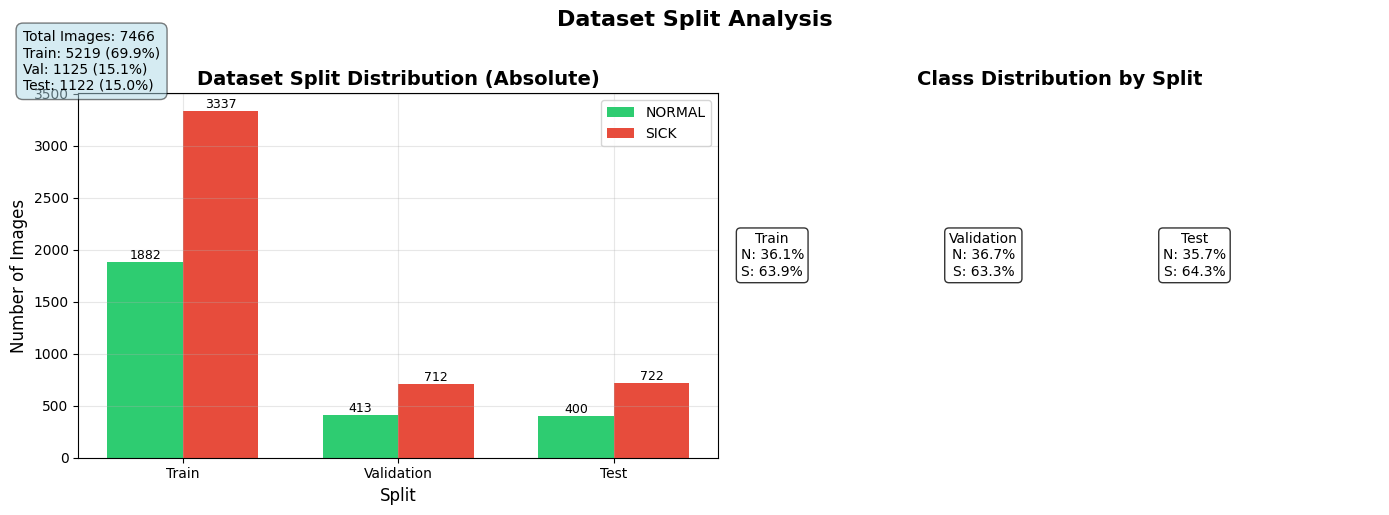

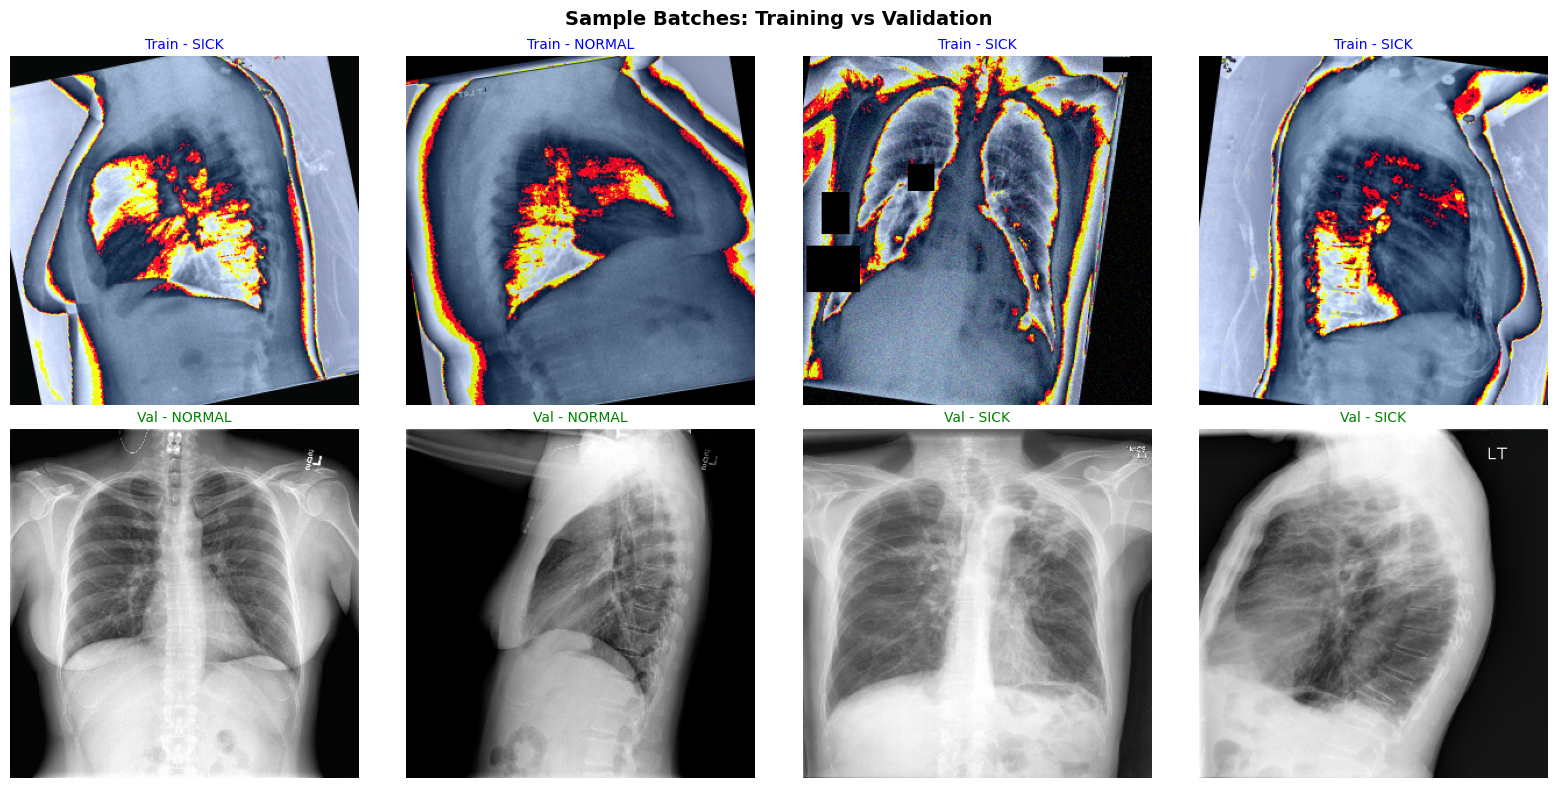

In [ ]:
def create_patient_based_split(path, val_split=0.15, test_split=0.15, random_seed=42):
    projections = pd.read_csv(Path(path) / 'indiana_projections.csv')
    reports = pd.read_csv(Path(path) / 'indiana_reports.csv')
    
    reports['label'] = reports['Problems'].apply(
        lambda x: 0 if pd.isna(x) or 'normal' in str(x).lower() else 1
    )
    
    merged = pd.merge(projections, reports[['uid', 'label']], on='uid', how='inner')
    
    unique_patients = merged[['uid', 'label']].drop_duplicates().reset_index(drop=True)
    
    print(f"\nPatient-level split:")
    print(f"Unique patients: {len(unique_patients)}")
    print(f"Normal patients: {sum(unique_patients['label'] == 0)}")
    print(f"Sick patients: {sum(unique_patients['label'] == 1)}")
    
    from sklearn.model_selection import train_test_split
    
    train_patients, temp_patients = train_test_split(
        unique_patients,
        test_size=val_split + test_split,
        stratify=unique_patients['label'],
        random_state=random_seed
    )
    
    val_patients, test_patients = train_test_split(
        temp_patients,
        test_size=test_split/(val_split+test_split),
        stratify=temp_patients['label'],
        random_state=random_seed
    )
    
    train_ids = set(train_patients['uid'].values)
    val_ids = set(val_patients['uid'].values)
    test_ids = set(test_patients['uid'].values)
    
    patient_ids = []
    for _, row in merged.iterrows():
        patient_ids.append(row['uid'])
    
    train_indices = [i for i, pid in enumerate(patient_ids) if pid in train_ids]
    val_indices = [i for i, pid in enumerate(patient_ids) if pid in val_ids]
    test_indices = [i for i, pid in enumerate(patient_ids) if pid in test_ids]
    
    print(f"\n   Train: {len(train_ids)} patients, {len(train_indices)} images")
    print(f"   Val: {len(val_ids)} patients, {len(val_indices)} images")
    print(f"   Test: {len(test_ids)} patients, {len(test_indices)} images")
    
    return train_indices, val_indices, test_indices, patient_ids
    
def create_data_loader(path, batch_size=32, num_workers=2, 
                       val_split=0.15, test_split=0.15):
    
    dataset = XRayDataset(
        path, 
        img_size=300, 
        transform=val_transform,
        augment=False, 
        use_projection="both"
    )
    
    train_indices, val_indices, test_indices, patient_ids = create_patient_based_split(
        path, val_split, test_split
    )
    
    train_dataset = AugmentedDataset(dataset, train_indices, train_transform)
    val_dataset = Subset(dataset, val_indices)
    test_dataset = Subset(dataset, test_indices)
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False,
        persistent_workers=False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True if torch.cuda.is_available() else False
    )
    
    print(f"\n Data Loader Summary:")
    print(f"Train: {len(train_loader)} batches ({len(train_indices)} images)")
    print(f"Val: {len(val_loader)} batches ({len(val_indices)} images)")
    print(f"Test: {len(test_loader)} batches ({len(test_indices)} images)")
    
    train_labels = [dataset.samples[i]['label'] for i in train_indices]
    class_weights = compute_class_weight(
        'balanced', 
        classes=np.unique(train_labels), 
        y=train_labels
    )
    class_weights = torch.FloatTensor(class_weights)
    print(f"   Class weights: Normal={class_weights[0]:.2f}, Sick={class_weights[1]:.2f}")
    
    return train_loader, val_loader, test_loader, class_weights, train_indices, val_indices, test_indices

train_loader, val_loader, test_loader, class_weights, train_indices, val_indices, test_indices = create_data_loader(
    DATA_DIR,
    batch_size=BATCH_SIZE, 
    num_workers=NUM_WORKERS, 
)

def visualize_split_distribution(dataset, train_indices, val_indices, test_indices, save_path=None):
    """
    PURPOSE: Verify that patient-based splitting created balanced splits
    WHY: Ensure no data leakage and balanced class distribution across splits
    """
    # Get labels for each split
    train_labels = [dataset.samples[i]['label'] for i in train_indices]
    val_labels = [dataset.samples[i]['label'] for i in val_indices]
    test_labels = [dataset.samples[i]['label'] for i in test_indices]
    
    # Calculate distributions
    splits = ['Train', 'Validation', 'Test']
    normal_counts = [
        sum(1 for l in train_labels if l == 0),
        sum(1 for l in val_labels if l == 0),
        sum(1 for l in test_labels if l == 0)
    ]
    sick_counts = [
        sum(1 for l in train_labels if l == 1),
        sum(1 for l in val_labels if l == 1),
        sum(1 for l in test_labels if l == 1)
    ]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot - Absolute counts
    x = np.arange(len(splits))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, normal_counts, width, label='NORMAL', color='#2ecc71')
    bars2 = ax1.bar(x + width/2, sick_counts, width, label='SICK', color='#e74c3c')
    
    ax1.set_xlabel('Split', fontsize=12)
    ax1.set_ylabel('Number of Images', fontsize=12)
    ax1.set_title('Dataset Split Distribution (Absolute)', fontsize=14, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(splits)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom', fontsize=9)
    
    # Pie charts for each split
    for i, (labels, split) in enumerate(zip([train_labels, val_labels, test_labels], splits)):
        normal_pct = sum(1 for l in labels if l == 0) / len(labels) * 100
        sick_pct = 100 - normal_pct
        
        ax2.text(i*0.33 + 0.05, 0.5, f'{split}\nN: {normal_pct:.1f}%\nS: {sick_pct:.1f}%',
                transform=ax2.transAxes, fontsize=10, ha='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_title('Class Distribution by Split', fontsize=14, fontweight='bold')
    ax2.axis('off')
    
    stats_text = f"Total Images: {len(dataset)}\n"
    stats_text += f"Train: {len(train_indices)} ({len(train_indices)/len(dataset)*100:.1f}%)\n"
    stats_text += f"Val: {len(val_indices)} ({len(val_indices)/len(dataset)*100:.1f}%)\n"
    stats_text += f"Test: {len(test_indices)} ({len(test_indices)/len(dataset)*100:.1f}%)"
    
    fig.text(0.02, 0.98, stats_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.5))
    
    plt.suptitle('Dataset Split Analysis', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Split distribution saved to {save_path}")
    
    plt.show()
    
def visualize_batch_samples(train_loader, val_loader, num_batches=2, save_path=None):
    """
    PURPOSE: See what the model ACTUALLY sees during training vs validation
    WHY: Verify augmentations are working correctly and not distorting images too much
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    
    try:
        train_batch, train_labels = next(iter(train_loader))
        
        for i in range(4):
            # Denormalize image
            img = train_batch[i].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = img * std + mean
            img = np.clip(img, 0, 1)
            
            axes[0, i].imshow(img)
            label = 'SICK' if train_labels[i] == 1 else 'NORMAL'
            axes[0, i].set_title(f'Train - {label}', fontsize=10, color='blue')
            axes[0, i].axis('off')
    except StopIteration:
        print("Training loader is empty!")
    
    # Validation batch
    try:
        val_batch, val_labels = next(iter(val_loader))
        
        for i in range(4):
            img = val_batch[i].cpu().permute(1, 2, 0).numpy()
            mean = np.array([0.485, 0.456, 0.406])
            std = np.array([0.229, 0.224, 0.225])
            img = img * std + mean
            img = np.clip(img, 0, 1)
            
            axes[1, i].imshow(img)
            label = 'SICK' if val_labels[i] == 1 else 'NORMAL'
            axes[1, i].set_title(f'Val - {label}', fontsize=10, color='green')
            axes[1, i].axis('off')
    except StopIteration:
        print("Validation loader is empty!")
    
    axes[0, 0].set_ylabel('TRAINING (with augmentation)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('VALIDATION (no augmentation)', fontsize=12, fontweight='bold')
    
    plt.suptitle('Sample Batches: Training vs Validation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"✅ Batch samples saved to {save_path}")
    
    plt.show()

visualize_split_distribution(dataset, train_indices, val_indices, test_indices)
visualize_batch_samples(train_loader, val_loader)

In [ ]:
# save the builded model
def save_complete_model(model, trainer=None, test_metrics=None, filepath='chest_xray_model.pth'):
    
    save_dict = {
        'model_state_dict': model.state_dict(),
        'model_architecture': 'efficientnet_b3',
        'classes': 2,
        'input_size': 300,
        'class_names': ['NORMAL', 'sick'],
        'normalization': {
            'mean': [0.485, 0.456, 0.406],
            'std': [0.229, 0.224, 0.225]
        },
        'date_saved': pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
    }
    
    if trainer:
        save_dict['training_history'] = {
            'train_loss': trainer.train_losses,
            'val_loss': trainer.val_losses,
            'train_acc': trainer.train_accs,
            'val_acc': trainer.val_accs,
            'best_val_acc': max(trainer.val_accs) if trainer.val_accs else None
        }
    
    if test_metrics:
        save_dict['test_metrics'] = test_metrics
    
    full_path = os.path.join(OUTPUT_DIR, filepath)
    torch.save(save_dict, full_path)
    print(f"saved on {full_path}")
    
    weights_path = os.path.join(OUTPUT_DIR, 'CHEST-XRay_weights.pth')
    torch.save(model.state_dict(), weights_path)
    print(f"Weights on {weights_path}")
    
    summary_path = os.path.join(OUTPUT_DIR, 'CHEST-XRayModel_summary.txt')
    with open(summary_path, 'w') as f:
        f.write("CHEST X-RAY CLASSIFICATION MODEL\n")
        f.write("="*40 + "\n")
        f.write(f"Model: EfficientNet-B3\n")
        f.write(f"Classes: NORMAL, sick\n")
        f.write(f"Input size: {IMG_SIZE}x{IMG_SIZE}\n")
        f.write(f"Saved: {save_dict['date_saved']}\n")
        
        if trainer and trainer.val_accs:
            f.write(f"\nBest validation accuracy: {max(trainer.val_accs):.2f}%\n")
        
        if test_metrics:
            f.write(f"\nTest accuracy: {test_metrics['accuracy']:.2f}%\n")
            f.write(f"Test AUC: {test_metrics['auc']:.4f}\n")
    
    print("Files saved in /kaggle/working/:")
    !ls -la /kaggle/working/*.pth /kaggle/working/*.txt 2>/dev/null || echo "No files found"
    
    return full_path


def plot_training_history(trainer, save_path=None):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(trainer.train_losses, 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(trainer.val_losses, 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(trainer.train_accs, 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(trainer.val_accs, 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    gap = [train - val for train, val in zip(trainer.train_accs, trainer.val_accs)]
    axes[2].plot(gap, 'g-', linewidth=2)
    axes[2].axhline(y=10, color='r', linestyle='--', label='Warning Threshold (10%)')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Gap (%)')
    axes[2].set_title('Train-Val Accuracy Gap')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"📊 Training plot saved to {save_path}")
    
    plt.show()
    
    print("\n" + "="*60)
    print("TRAINING SUMMARY")
    print("="*60)
    print(f"Best Validation Accuracy: {max(trainer.val_accs):.2f}% (Epoch {trainer.val_accs.index(max(trainer.val_accs))+1})")
    print(f"Best Validation Loss: {min(trainer.val_losses):.4f} (Epoch {trainer.val_losses.index(min(trainer.val_losses))+1})")
    print(f"Final Train Accuracy: {trainer.train_accs[-1]:.2f}%")
    print(f"Final Val Accuracy: {trainer.val_accs[-1]:.2f}%")
    print(f"Final Gap: {trainer.train_accs[-1] - trainer.val_accs[-1]:.1f}%")
    
    if max(gap) > 15:
        print(f"\nWARNING: Large overfitting detected (max gap: {max(gap):.1f}%)")
        print("   Consider: more augmentation, higher dropout, or earlier stopping")
    elif max(gap) > 10:
        print(f"\nMild overfitting detected (max gap: {max(gap):.1f}%)")
    else:
        print(f"\nGood generalization! (max gap: {max(gap):.1f}%)")


def evaluate_and_visualize(model, test_loader, device, class_names=['NORMAL', 'sick']):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)
    print(f"Accuracy:  {accuracy:.2f}%")
    print(f"AUC-ROC:   {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return accuracy, auc


def visualize_predictions(model, test_loader, device, num_samples=6, save_path=None):
    model.eval()
    
    images, labels = next(iter(test_loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(num_samples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        true_label = 'sick' if labels[i] == 1 else 'normal'
        pred_label = 'sick' if preds[i] == 1 else 'normal'
        confidence = probs[i][preds[i]].item() * 100
        is_correct = preds[i] == labels[i]
        
        title_color = 'green' if is_correct else 'red'
        confidence_color = 'darkgreen' if confidence > 80 else 'orange' if confidence > 60 else 'red'
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", 
                          color=title_color)
        axes[i].axis('off')
        
        axes[i].text(10, 30, f"Confidence: {confidence:.1f}%", 
                     color=confidence_color, fontsize=9, weight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Predictions visualization saved to {save_path}")
    
    plt.show()

def evaluate_and_visualize(model, test_loader, device, class_names=['NORMAL', 'sick']):
    model.eval()
    all_labels = []
    all_preds = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    try:
        auc = roc_auc_score(all_labels, all_probs)
    except:
        auc = 0.0
    
    print("\n" + "="*60)
    print("TEST SET EVALUATION")
    print("="*60)
    print(f"Accuracy:  {accuracy:.2f}%")
    print(f"AUC-ROC:   {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title('Confusion Matrix - Test Set')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()
    
    return accuracy, auc


def visualize_predictions(model, test_loader, device, num_samples=6, save_path=None):
    model.eval()
    
    images, labels = next(iter(test_loader))
    images = images[:num_samples].to(device)
    labels = labels[:num_samples]
    
    with torch.no_grad():
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i in range(num_samples):
        img = images[i].cpu().permute(1, 2, 0).numpy()
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = img * std + mean
        img = np.clip(img, 0, 1)
        
        true_label = 'sick' if labels[i] == 1 else 'normal'
        pred_label = 'sick' if preds[i] == 1 else 'normal'
        confidence = probs[i][preds[i]].item() * 100
        is_correct = preds[i] == labels[i]
        
        title_color = 'green' if is_correct else 'red'
        confidence_color = 'darkgreen' if confidence > 80 else 'orange' if confidence > 60 else 'red'
        
        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", 
                          color=title_color)
        axes[i].axis('off')
        
        axes[i].text(10, 30, f"Confidence: {confidence:.1f}%", 
                     color=confidence_color, fontsize=9, weight='bold',
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Predictions visualization saved to {save_path}")
    
    plt.show()

using device: cuda
[DEBUG] Total params: 10,796,874, Trainable: 10,772,076 (99.8%)
Total parameters: 10,796,874
Trainable parameters: 10,772,076
Trainable %: 99.8%
Using weighted loss: [1.3865569 0.7819898]
[DEBUG] Train batches: 327
[DEBUG] Val batches: 71
[DEBUG] Early stopping patience: 5

Starting training for up to 20 epochs
Early stopping patience: 5

[DEBUG] EPOCH 1/20



Training: 100%|██████████| 327/327 [02:09<00:00,  2.52it/s, Loss=1.1318, Acc=48.19%]


[DEBUG] Train Epoch Summary - Loss: 0.7377, Acc: 48.19%


Validating: 100%|██████████| 71/71 [00:22<00:00,  3.14it/s]


[DEBUG] Validation Summary - Loss: 0.6840, Acc: 59.20%
[DEBUG] Training: Loss -> 0.7377, Acc -> 48.19
[DEBUG] Validation: Loss -> 0.6840, Acc -> 59.20
[DEBUG] LR: 0.000100
[DEBUG] ✓ Saved best model with Val Acc: 59.20%
[DEBUG] EPOCH 2/20



...

[DEBUG] Train Epoch Summary - Loss: 0.4689, Acc: 79.23%


Validating: 100%|██████████| 71/71 [00:21<00:00,  3.24it/s]


[DEBUG] Validation Summary - Loss: 0.7551, Acc: 67.82%
[DEBUG] Training: Loss -> 0.4689, Acc -> 79.23
[DEBUG] Validation: Loss -> 0.7551, Acc -> 67.82
[DEBUG] LR: 0.000050
[WARNING] Large train-val gap (11.4%) - overfitting detected!
[DEBUG] No improvement for 5/5 epochs

EARLY STOPPING triggered at epoch 12
Best validation accuracy: 70.49%
Final gap: 11.4%


Training completed!
Best validation accuracy: 70.49%
Final train accuracy: 79.23%
Final val accuracy: 67.82%
Final gap: 11.4%


Loaded best model from epoch 7
Validation Accuracy: 70.49%


Evaluating: 100%|██████████| 71/71 [00:21<00:00,  3.25it/s]



TEST SET EVALUATION
Accuracy:  71.48%
AUC-ROC:   0.7674

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.66      0.41      0.51       400
        sick       0.73      0.88      0.80       722

    accuracy                           0.71      1122
   macro avg       0.69      0.65      0.65      1122
weighted avg       0.71      0.71      0.70      1122



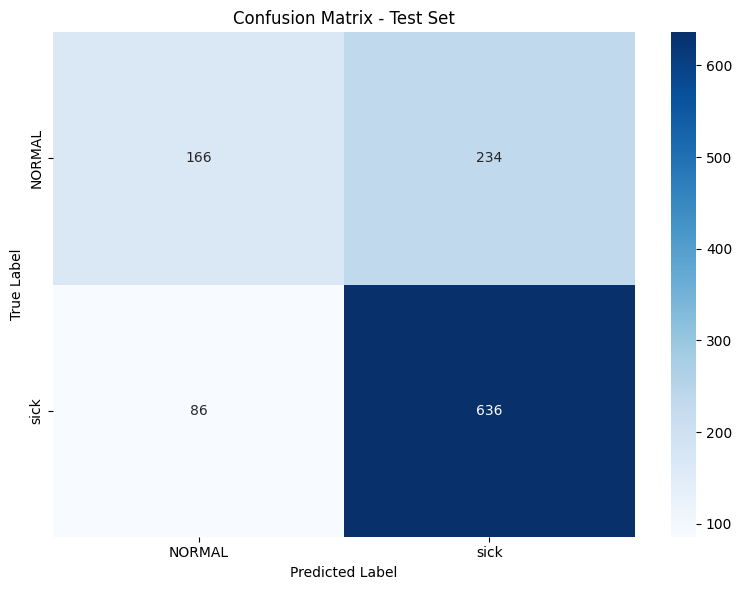


FINAL RESULTS
Best Validation Accuracy: 70.49%
Test Accuracy: 71.48%
Test AUC: 0.7674


In [ ]:
if __name__ == "__main__":
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
    torch.cuda.empty_cache()
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"using device: {device}")
    
    model = EfficientNetModel(classes=2, pretrained=True)
    model = model.to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")
    print(f"Trainable %: {trainable_params/total_params*100:.1f}%")
    
    class_weights = class_weights.to(device)
    loss_func = nn.CrossEntropyLoss(weight=class_weights)
    print(f"Using weighted loss: {class_weights.cpu().numpy()}")
        
    backbone_params = []
    head_params = []
    
    for name, param in model.named_parameters():
        if "backbone" in name and param.requires_grad:
            backbone_params.append(param)
        elif param.requires_grad:
            head_params.append(param)
        
    optimizer = optim.AdamW([
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params, "lr": 5e-4}
    ], weight_decay=3e-5)
    
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=NUM_EPOCHS,
        eta_min=1e-6
    )
    
    trainer = Trainer(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        loss_func=loss_func,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device
    )
    
    trained_model = trainer.train(num_epochs=NUM_EPOCHS)
    
    if os.path.exists('chest_xray_model.pth'):
        checkpoint = torch.load('chest_xray_model.pth', map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"\nLoaded best model from epoch {checkpoint['epoch']+1}")
        print(f"Validation Accuracy: {checkpoint['val_acc']:.2f}%")
    
    test_acc, test_auc = evaluate_and_visualize(model, test_loader, device)
    
    print(f"\n{'='*60}")
    print(f"FINAL RESULTS")
    print(f"{'='*60}")
    print(f"Best Validation Accuracy: {trainer.best_val_acc:.2f}%")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print(f"Test AUC: {test_auc:.4f}")
    print(f"{'='*60}")